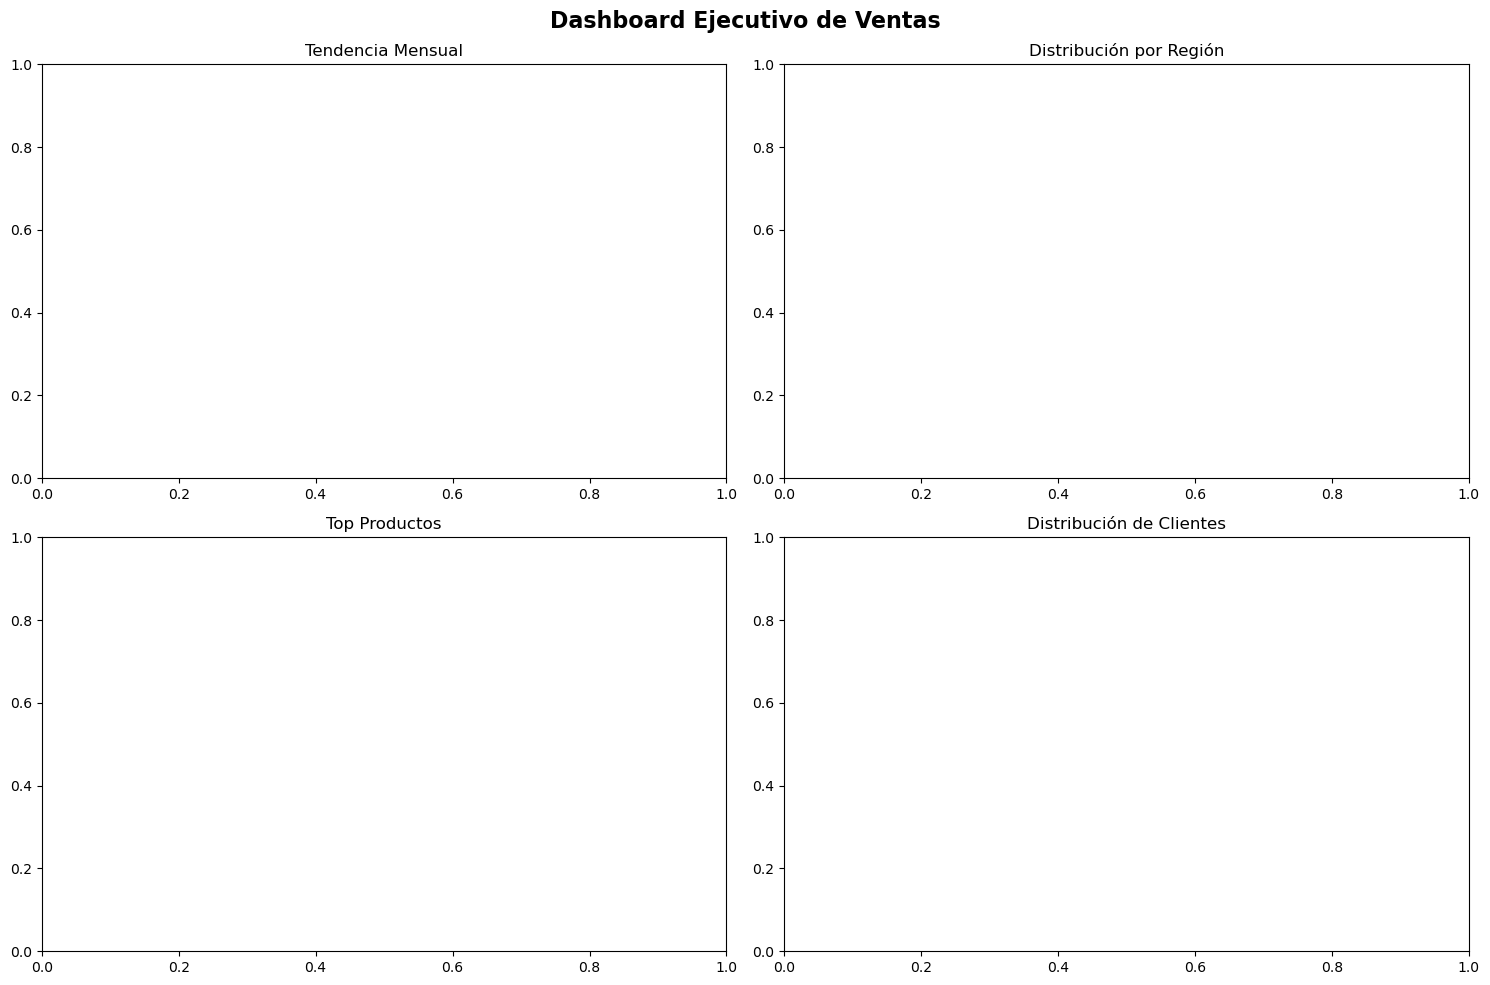

In [2]:
import matplotlib.pyplot as plt
# 2x2 grid para análisis multivariado
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Dashboard Ejecutivo de Ventas', fontsize=16, fontweight='bold')

# Asignar visualizaciones específicas
ax1.set_title('Tendencia Mensual')      # Serie temporal
ax2.set_title('Distribución por Región') # Barras
ax3.set_title('Top Productos')          # Barras horizontales
ax4.set_title('Distribución de Clientes') # Pie o barras

plt.tight_layout()

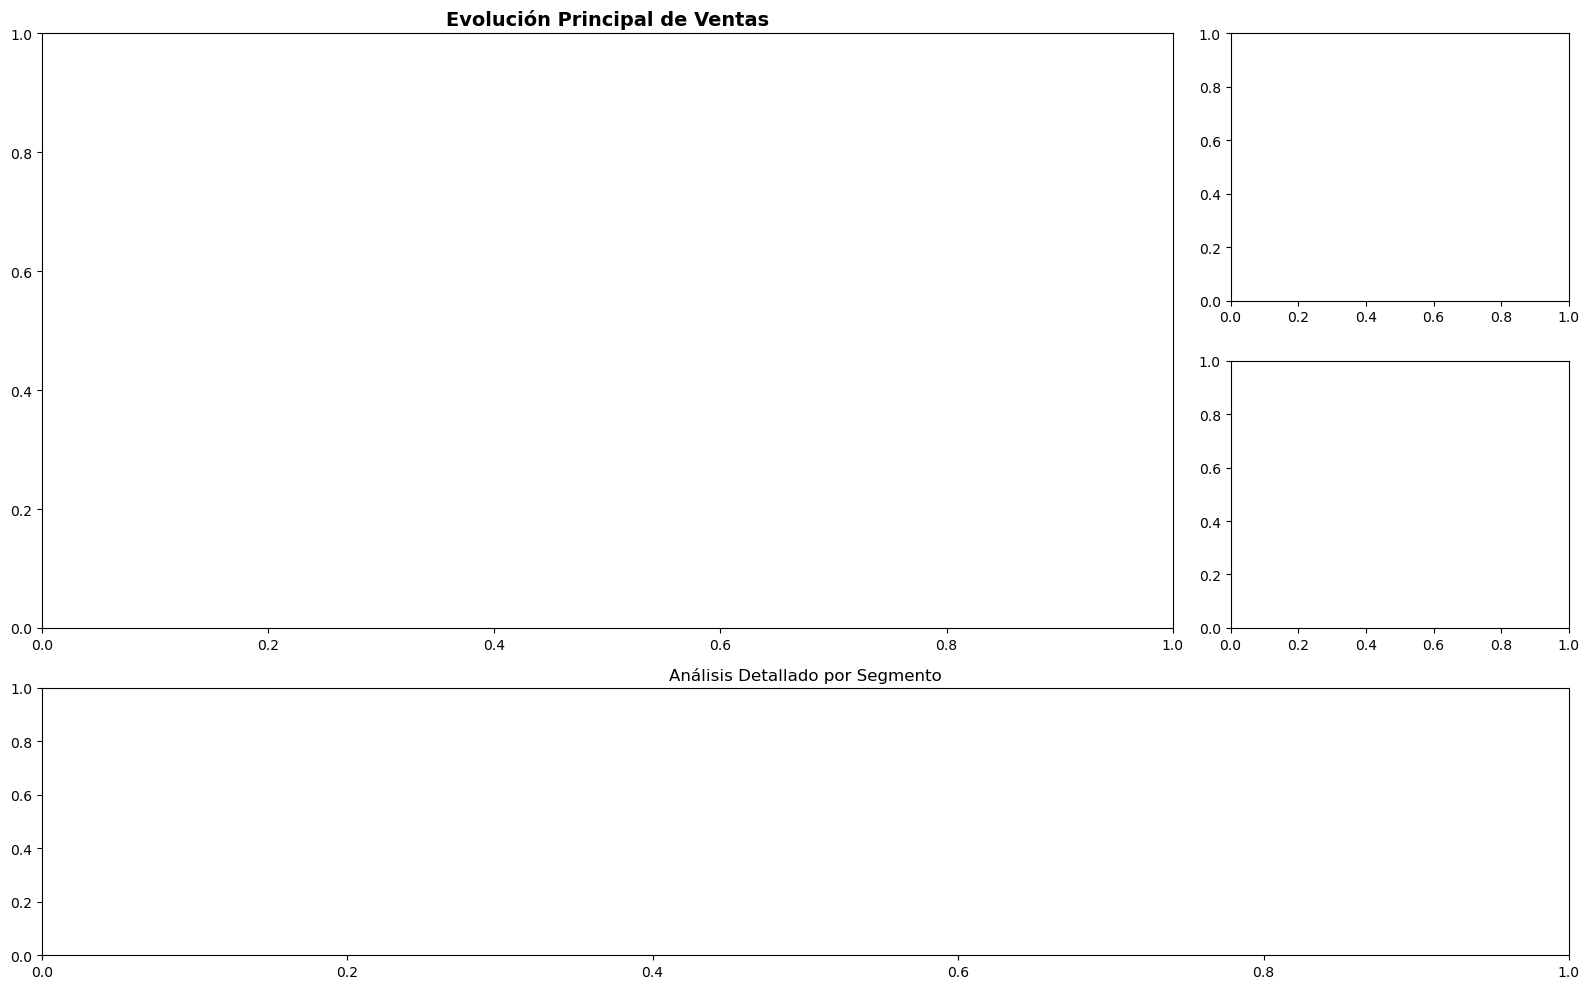

In [3]:
# Layout asimétrico
# Layout con gráfico principal y secundarios
fig = plt.figure(figsize=(16, 10))

# Gráfico principal (70% del espacio)
ax_main = plt.subplot2grid((3, 4), (0, 0), colspan=3, rowspan=2)
ax_main.set_title('Evolución Principal de Ventas', fontsize=14, fontweight='bold')

# Panel derecho con KPIs (30% del espacio)
ax_kpi1 = plt.subplot2grid((3, 4), (0, 3), rowspan=1)
ax_kpi2 = plt.subplot2grid((3, 4), (1, 3), rowspan=1)

# Panel inferior para detalles
ax_detail = plt.subplot2grid((3, 4), (2, 0), colspan=4)
ax_detail.set_title('Análisis Detallado por Segmento', fontsize=12)

plt.tight_layout()

NameError: name 'df' is not defined

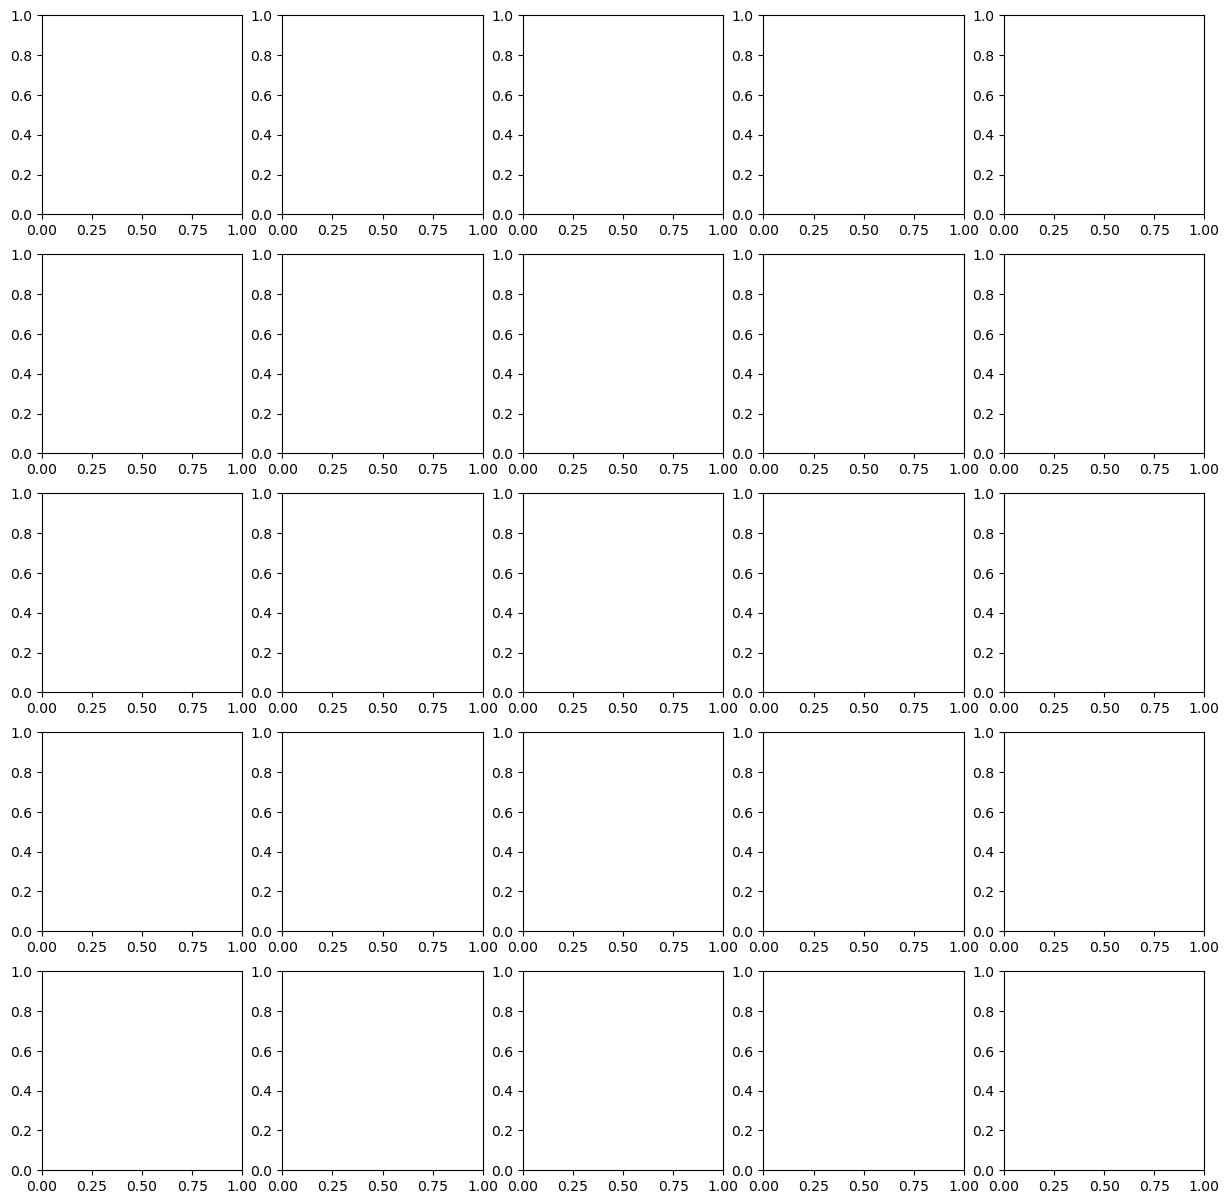

In [7]:
# Variables de interés para análisis multivariado
variables_clave = ['ventas', 'margen', 'satisfaccion', 'retencion', 'valor_vida']

# Crear scatter plot matrix
n_vars = len(variables_clave)
fig, axes = plt.subplots(n_vars, n_vars, figsize=(15, 15))

for i in range(n_vars):
    for j in range(n_vars):
        ax = axes[i, j]
        
        if i == j:
            # Diagonal: histogramas
            ax.hist(df[variables_clave[i]], bins=20, alpha=0.7, color=colores[0])
            ax.set_title(f'{variables_clave[i].title()}', fontsize=10)
        else:
            # Off-diagonal: scatter plots
            ax.scatter(df[variables_clave[j]], df[variables_clave[i]], 
                      alpha=0.6, s=30, color=colores[1])
            
            # Añadir línea de tendencia si correlación fuerte
            corr = df[variables_clave[j]].corr(df[variables_clave[i]])
            if abs(corr) > 0.5:
                z = np.polyfit(df[variables_clave[j]], df[variables_clave[i]], 1)
                p = np.poly1d(z)
                x_trend = np.linspace(df[variables_clave[j]].min(), df[variables_clave[j]].max(), 50)
                ax.plot(x_trend, p(x_trend), 'r--', alpha=0.8, linewidth=1)

# Configurar etiquetas
for i, var in enumerate(variables_clave):
    axes[-1, i].set_xlabel(var.title(), fontsize=10)
    axes[i, 0].set_ylabel(var.title(), fontsize=10)

plt.suptitle('Matriz de Relaciones Multivariadas', fontsize=14, fontweight='bold', y=0.95)
plt.tight_layout()
plt.savefig('scatter_matrix_multivariada.png', dpi=300, bbox_inches='tight')

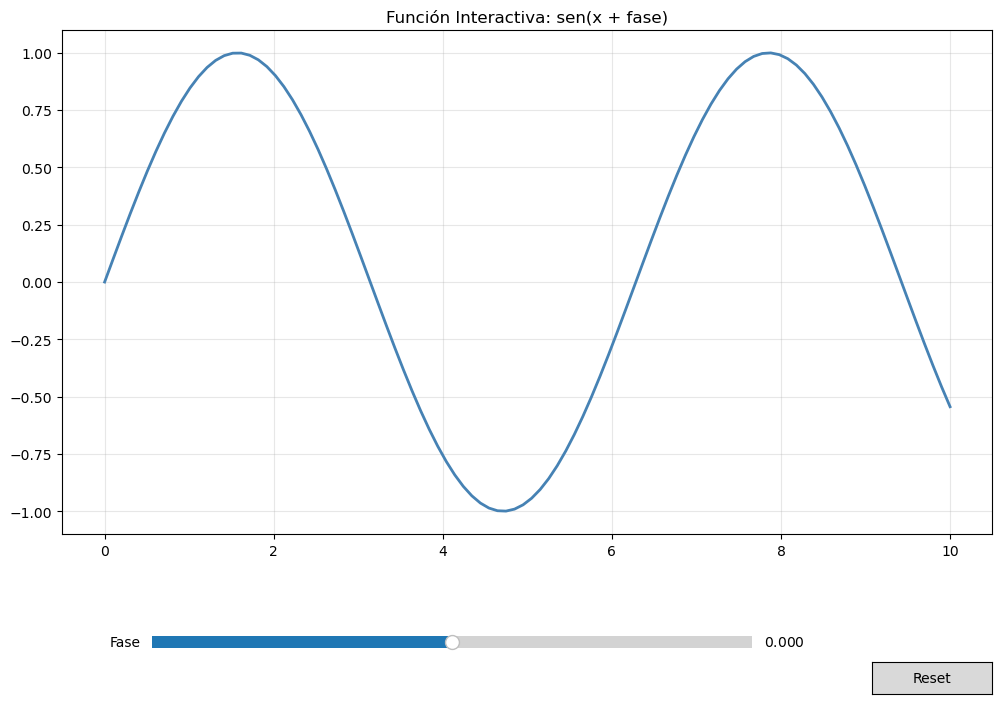

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, Button

# Configurar figura con espacio para controles
fig, ax = plt.subplots(figsize=(12, 8))
plt.subplots_adjust(bottom=0.25)
colores = ["steelblue", "darkorange", "green", "red"]




# Gráfico inicial
x = np.linspace(0, 10, 100)
line, = ax.plot(x, np.sin(x), linewidth=2, color=colores[0])
ax.set_title('Función Interactiva: sen(x + fase)')
ax.grid(True, alpha=0.3)

# Crear slider para fase
ax_phase = plt.axes([0.2, 0.1, 0.5, 0.03])
slider_phase = Slider(ax_phase, 'Fase', -np.pi, np.pi, valinit=0)

# Función de actualización
def update(val):
    phase = slider_phase.val
    line.set_ydata(np.sin(x + phase))
    fig.canvas.draw_idle()

# Conectar slider a función de actualización
slider_phase.on_changed(update)

# Botón de reset
ax_reset = plt.axes([0.8, 0.05, 0.1, 0.04])
button_reset = Button(ax_reset, 'Reset')

def reset(event):
    slider_phase.set_val(0)
    update(0)

button_reset.on_clicked(reset)

plt.show()

In [14]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
data = {
    "region": ["Norte", "Sur", "Este", "Oeste", "Norte", "Sur"],
    "total_venta": [1000, 1200, 900, 800, 1100, 1300],
    "fecha": pd.date_range("2024-01-01", periods=6, freq="M"),
    "producto": ["A", "B", "C", "D", "A", "B"]
}

df = pd.DataFrame(data)




# Crear subplot interactivo
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Ventas por Región', 'Tendencia Temporal', 
                   'Distribución por Producto', 'Top Clientes'),
    specs=[[{'type': 'bar'}, {'type': 'scatter'}],
           [{'type': 'pie'}, {'type': 'bar'}]]
)

# Gráfico 1: Barras de ventas por región
ventas_region = df.groupby('region')['total_venta'].sum()
fig.add_trace(
    go.Bar(x=ventas_region.index, y=ventas_region.values, 
           name='Ventas por Región', marker_color=colores[0]),
    row=1, col=1
)

# Gráfico 2: Tendencia temporal
ventas_tiempo = df.groupby('fecha')['total_venta'].sum().reset_index()
fig.add_trace(
    go.Scatter(x=ventas_tiempo['fecha'], y=ventas_tiempo['total_venta'],
              mode='lines+markers', name='Evolución de Ventas',
              line=dict(color=colores[1], width=3)),
    row=1, col=2
)

# Gráfico 3: Pie chart de productos
ventas_producto = df.groupby('producto')['total_venta'].sum()
fig.add_trace(
    go.Pie(labels=ventas_producto.index, values=ventas_producto.values,
           name='Distribución por Producto'),
    row=2, col=1
)

"""# Gráfico 4: Top clientes
top_clientes = df.groupby('cliente')['total_venta'].sum().nlargest(10)
fig.add_trace(
    go.Bar(x=top_clientes.values, y=top_clientes.index, orientation='h',
           name='Top 10 Clientes', marker_color=colores[3]),
    row=2, col=2
)"""

# Configurar layout
fig.update_layout(
    title_text='Dashboard Interactivo de Ventas Empresariales',
    title_font_size=20,
    showlegend=False,
    height=800
)

# Guardar como HTML interactivo
fig.write_html('dashboard_interactivo.html')
print("Dashboard interactivo guardado como 'dashboard_interactivo.html'")

Dashboard interactivo guardado como 'dashboard_interactivo.html'


C:\Users\mfram\anaconda31\Lib\site-packages\_plotly_utils\basevalidators.py:106: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result

